# 03 - Model Building and Evaluation

## Fuel Efficiency Prediction Project

In this notebook, we build machine learning regression models to predict car fuel efficiency.

The target variable is:

`mpg`

MPG means **Miles Per Gallon**. Higher MPG means better fuel efficiency.

We will train and compare different regression models:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting Regressor

The goal is to find which model gives the best prediction performance.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Show all columns clearly
pd.set_option("display.max_columns", None)

## 1. Load the Cleaned Dataset

We use the cleaned dataset created in Notebook 02.

This cleaned dataset already contains:

- Handled missing values
- Removed unnecessary columns
- Engineered new features
- Encoded categorical variables

So now it is ready for machine learning.

In [2]:
# Load cleaned dataset

df = pd.read_csv("../data/auto_mpg_cleaned.csv")

# Display first 5 rows
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,power_to_weight,displacement_per_cyl,is_v8,decade,origin_Japan,origin_USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,37.100457,38.375,1,70,0,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,44.679123,43.750,1,70,0,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,43.655413,39.750,1,70,0,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,43.693562,38.000,1,70,0,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,40.591476,37.750,1,70,0,1


## 2. Check Dataset Information

Before model training, we check the dataset again to make sure everything is correct.

In [3]:
# Check dataset shape

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 398
Columns: 13


In [4]:
# Check missing values

df.isnull().sum()

mpg                     0
cylinders               0
displacement            0
horsepower              0
weight                  0
acceleration            0
model_year              0
power_to_weight         0
displacement_per_cyl    0
is_v8                   0
decade                  0
origin_Japan            0
origin_USA              0
dtype: int64

## 3. Separate Features and Target

For machine learning, we need to separate the dataset into:

### Features - X

These are the input columns used to make predictions.

### Target - y

This is the value we want to predict.

In this project:

- `X` = car-related features
- `y` = `mpg`

In [6]:
# Separate target variable

X = df.drop("mpg", axis=1)
y = df["mpg"]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

# Display feature columns
X.columns


Feature data shape: (398, 12)
Target data shape: (398,)


Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model_year', 'power_to_weight', 'displacement_per_cyl', 'is_v8',
       'decade', 'origin_Japan', 'origin_USA'],
      dtype='str')

## 4. Split Data into Training and Testing Sets

We split the data into two parts:

### Training Set

Used to train the machine learning model.

### Testing Set

Used to check how well the model performs on unseen data.

We use:

- 80% data for training
- 20% data for testing

In [7]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (318, 12)
X_test shape: (80, 12)
y_train shape: (318,)
y_test shape: (80,)


## 5. Feature Scaling

Feature scaling helps some models perform better.

Linear Regression can be affected by different feature scales.

For example:

- `weight` has large values
- `origin_Europe` has only 0 or 1 values

So we scale the data for Linear Regression.

Tree-based models like Decision Tree, Random Forest, and Gradient Boosting do not strictly require scaling, but keeping scaled versions is useful for comparison.

In [8]:
# Create StandardScaler object

scaler = StandardScaler()

# Fit scaler only on training data and transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")

Scaling completed successfully!


## 6. Create Evaluation Function

We create one function to evaluate all models.

This function calculates:

### R² Score

Shows how well the model explains the target variable.

Higher R² is better.

### RMSE

Root Mean Squared Error.

Shows average prediction error. Lower RMSE is better.

### MAE

Mean Absolute Error.

Shows average absolute difference between actual and predicted MPG. Lower MAE is better.

In [9]:
# Function to evaluate regression model performance

def evaluate_model(model_name, y_true, y_pred):
    """
    This function calculates common regression metrics.
    
    Parameters:
    model_name: Name of the machine learning model
    y_true: Actual MPG values
    y_pred: Predicted MPG values
    
    Returns:
    Dictionary containing model performance metrics
    """
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    print("=" * 45)
    print(model_name)
    print("=" * 45)
    print("R2 Score:", round(r2, 4))
    print("RMSE:", round(rmse, 4))
    print("MAE:", round(mae, 4))
    
    return {
        "Model": model_name,
        "R2 Score": r2,
        "RMSE": rmse,
        "MAE": mae
    }

## 7. Model 1 - Linear Regression

Linear Regression is a simple baseline regression model.

It tries to find a straight-line relationship between input features and the target variable.

We use it first because it is easy to understand and useful as a baseline model.

In [10]:
# Create Linear Regression model

linear_model = LinearRegression()

# Train the model using scaled training data
linear_model.fit(X_train_scaled, y_train)

# Make predictions using scaled test data
y_pred_linear = linear_model.predict(X_test_scaled)

# Evaluate model
linear_results = evaluate_model("Linear Regression", y_test, y_pred_linear)

Linear Regression
R2 Score: 0.8807
RMSE: 2.5324
MAE: 1.933


### Linear Regression Observation

Linear Regression gives us a simple baseline result.

If more advanced models perform better than this model, then we know non-linear models are more suitable for this dataset.

## 8. Model 2 - Decision Tree Regressor

Decision Tree is a tree-based model.

It makes predictions by splitting data into smaller groups based on feature values.

Advantages:

- Easy to understand
- Can capture non-linear patterns
- Does not require feature scaling

Disadvantage:

- Can overfit if the tree becomes too deep

In [11]:
# Create Decision Tree model

decision_tree = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

# Train the model
decision_tree.fit(X_train, y_train)

# Make predictions
y_pred_tree = decision_tree.predict(X_test)

# Evaluate model
tree_results = evaluate_model("Decision Tree Regressor", y_test, y_pred_tree)

Decision Tree Regressor
R2 Score: 0.8043
RMSE: 3.2438
MAE: 2.227


### Decision Tree Observation

Decision Tree can learn non-linear patterns better than Linear Regression.

However, if the tree is too complex, it may memorize the training data and perform poorly on test data.

## 9. Model 3 - Random Forest Regressor

Random Forest is an ensemble model.

It builds many decision trees and combines their predictions.

Advantages:

- Usually more accurate than a single Decision Tree
- Reduces overfitting
- Handles non-linear relationships well
- Works well for tabular data

This is usually one of the strongest models for beginner machine learning projects.

In [12]:
# Create Random Forest model

random_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

# Train the model
random_forest.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest.predict(X_test)

# Evaluate model
rf_results = evaluate_model("Random Forest Regressor", y_test, y_pred_rf)


Random Forest Regressor
R2 Score: 0.9179
RMSE: 2.101
MAE: 1.5761


### Random Forest Observation

Random Forest usually performs better than a single Decision Tree because it uses many trees together.

It is useful for this project because car fuel efficiency depends on several non-linear relationships.

## 10. Model 4 - Gradient Boosting Regressor

Gradient Boosting is another ensemble learning model.

It builds models one after another.

Each new model tries to correct the errors made by the previous model.

Advantages:

- Often gives strong prediction performance
- Good for structured/tabular datasets
- Can capture complex patterns

Disadvantage:

- More sensitive to parameter settings than Random Forest

In [13]:
# Create Gradient Boosting model

gradient_boosting = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train the model
gradient_boosting.fit(X_train, y_train)

# Make predictions
y_pred_gb = gradient_boosting.predict(X_test)

# Evaluate model
gb_results = evaluate_model("Gradient Boosting Regressor", y_test, y_pred_gb)

Gradient Boosting Regressor
R2 Score: 0.8994
RMSE: 2.3262
MAE: 1.7333


### Gradient Boosting Observation

Gradient Boosting can perform very well because it improves step by step.

If it gives high accuracy and low error, it can be considered one of the best models for this project.

## 11. Compare Model Performance

Now we compare all models using a table.

The best model should have:

- Highest R² Score
- Lowest RMSE
- Lowest MAE

In [14]:
# Store all model results in one list

results = [
    linear_results,
    tree_results,
    rf_results,
    gb_results
]

# Convert results into DataFrame
results_df = pd.DataFrame(results)

# Sort models by R2 Score
results_df = results_df.sort_values(by="R2 Score", ascending=False)

results_df

,Model,R2 Score,RMSE,MAE
2,Random Forest Regressor,0.917898,2.101035,1.576119
3,Gradient Boosting Regressor,0.899354,2.326239,1.733300
0,Linear Regression,0.880726,2.532382,1.932951
1,Decision Tree Regressor,0.804293,3.243837,2.227022


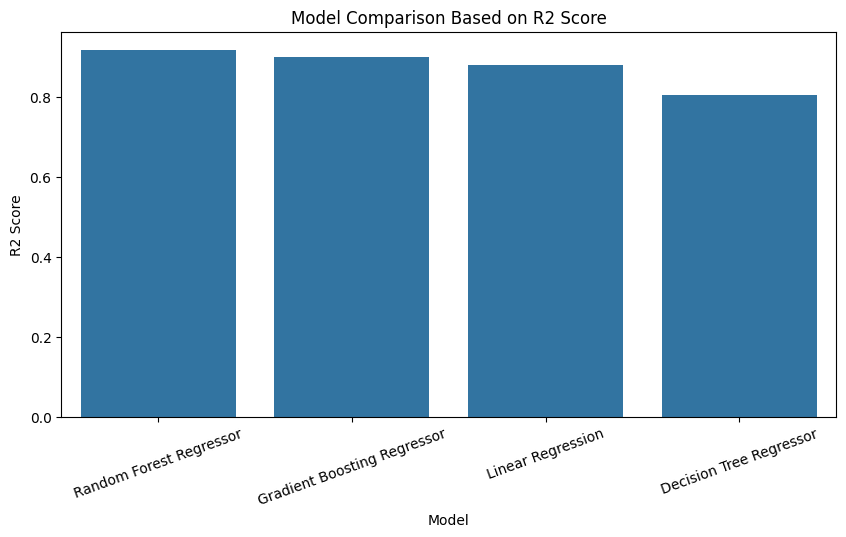

In [15]:
# Visualize model comparison using R2 Score

plt.figure(figsize=(10, 5))

sns.barplot(data=results_df, x="Model", y="R2 Score")

plt.title("Model Comparison Based on R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)

plt.show()

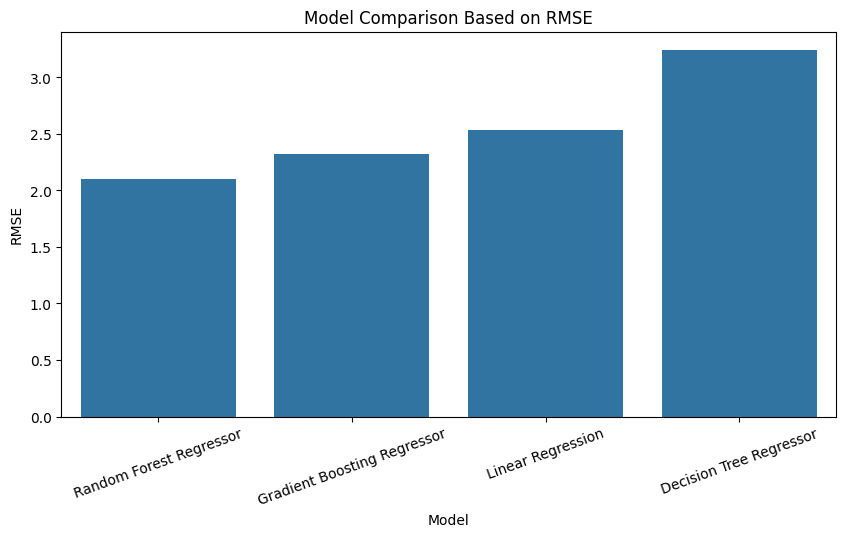

In [16]:
# Visualize model comparison using RMSE

plt.figure(figsize=(10, 5))

sns.barplot(data=results_df, x="Model", y="RMSE")

plt.title("Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)

plt.show()

### Model Comparison Observation

The comparison table and charts help us identify the best model.

The best model is the one with:

- Higher R² Score
- Lower RMSE
- Lower MAE

For this dataset, tree-based ensemble models such as Random Forest and Gradient Boosting usually perform better than simple Linear Regression.

## 12. Actual vs Predicted Values

Now we compare actual MPG values with predicted MPG values.

If the model is good, predicted values should be close to actual values.

In [17]:
# Select best model automatically based on highest R2 Score

best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Random Forest Regressor


In [18]:
# Choose prediction values of the best model

if best_model_name == "Linear Regression":
    best_predictions = y_pred_linear
elif best_model_name == "Decision Tree Regressor":
    best_predictions = y_pred_tree
elif best_model_name == "Random Forest Regressor":
    best_predictions = y_pred_rf
else:
    best_predictions = y_pred_gb

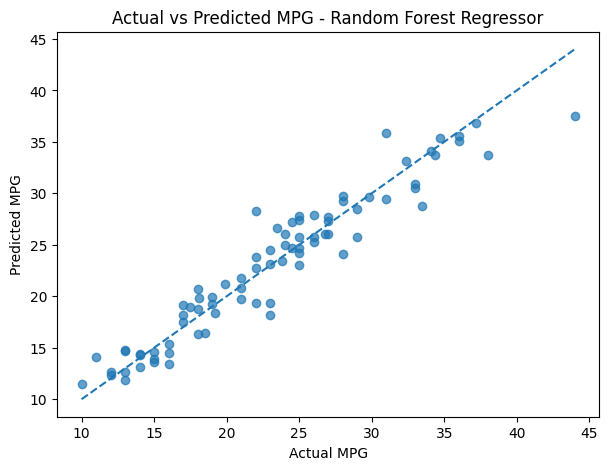

In [19]:
# Plot actual vs predicted MPG values

plt.figure(figsize=(7, 5))

plt.scatter(y_test, best_predictions, alpha=0.7)

# Perfect prediction reference line
min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.title(f"Actual vs Predicted MPG - {best_model_name}")
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")

plt.show()

### Actual vs Predicted Observation

This graph shows how close the predicted MPG values are to the actual MPG values.

If most points are near the diagonal line, the model is performing well.

Large distances from the line show prediction errors.

## 13. Residual Analysis

Residual means the difference between actual value and predicted value.

Formula:

`Residual = Actual MPG - Predicted MPG`

A good model should have residuals randomly spread around zero.

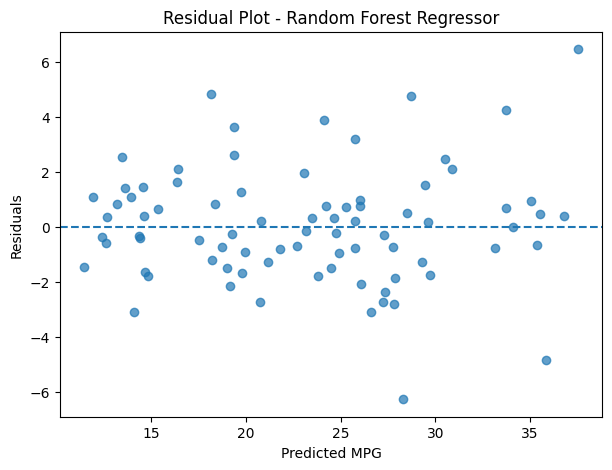

In [20]:
# Calculate residuals

residuals = y_test - best_predictions

# Plot residuals
plt.figure(figsize=(7, 5))

plt.scatter(best_predictions, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")

plt.title(f"Residual Plot - {best_model_name}")
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")

plt.show()

### Residual Observation

The residual plot helps us understand prediction errors.

A good model should show:

- Residuals scattered around zero
- No clear pattern
- Few very large errors

If residuals show a strong pattern, the model may not be capturing all relationships properly.

## 14. Feature Importance

Feature importance shows which input features are most useful for prediction.

This is available for tree-based models such as:

- Decision Tree
- Random Forest
- Gradient Boosting

Here, we check feature importance from the Random Forest model.

In [21]:
# Get feature importance from Random Forest model

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
1,displacement,0.387216
3,weight,0.161730
0,cylinders,0.141169
2,horsepower,0.114599
5,model_year,0.106435
7,displacement_per_cyl,0.038096
4,acceleration,0.021316
6,power_to_weight,0.018111
9,decade,0.006780
10,origin_Japan,0.002515


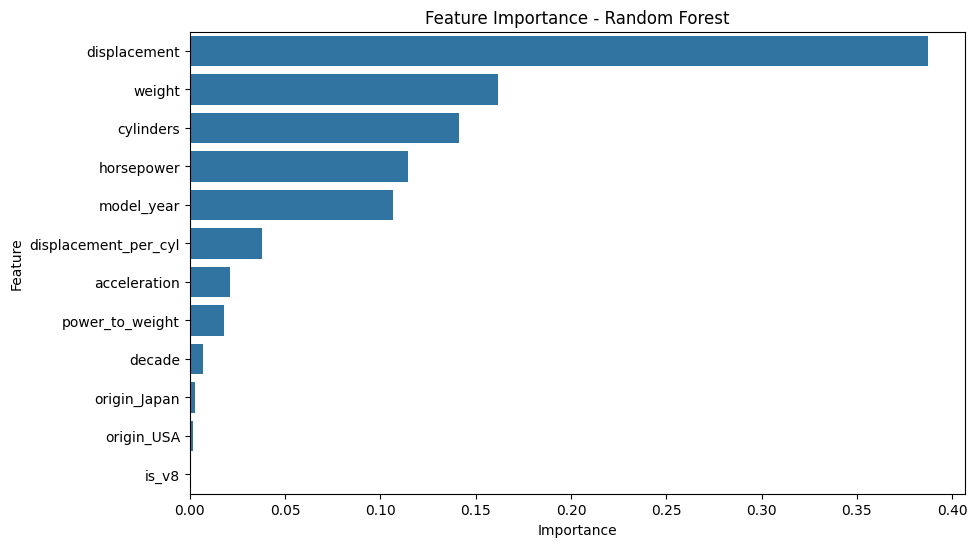

In [22]:
# Plot top feature importance values

plt.figure(figsize=(10, 6))

sns.barplot(data=feature_importance, x="Importance", y="Feature")

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Feature Importance Observation

Feature importance helps us understand what the model depends on most.

In fuel efficiency prediction, features like:

- `weight`
- `horsepower`
- `displacement`
- `model_year`

are usually very important because they directly affect vehicle fuel consumption.

## 15. Cross Validation

Cross validation checks model performance more reliably.

Instead of testing the model only once, it splits the data into multiple parts and tests the model several times.

Here, we use 5-fold cross validation for the Random Forest model.

In [23]:
# Perform 5-fold cross validation on Random Forest

cv_scores = cross_val_score(
    random_forest,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation R2 Scores:", cv_scores)
print("Mean CV R2 Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation R2 Scores: [0.89992695 0.84529136 0.87919318 0.77563132 0.38458513]
Mean CV R2 Score: 0.756925589747593
Standard Deviation: 0.19088980174162673


### Cross Validation Observation

Cross validation gives a more reliable idea about model performance.

If the scores are close to each other, the model is stable.

If the scores are very different, the model performance changes depending on the data split.

## 16. Final Model Building Summary

In this notebook, we completed the model building process.

Main tasks completed:

1. Loaded the cleaned dataset
2. Separated features and target variable
3. Split data into training and testing sets
4. Applied feature scaling
5. Trained four regression models:
   - Linear Regression
   - Decision Tree Regressor
   - Random Forest Regressor
   - Gradient Boosting Regressor
6. Evaluated models using:
   - R² Score
   - RMSE
   - MAE
7. Compared model performance
8. Visualized actual vs predicted values
9. Analyzed residuals
10. Checked feature importance
11. Used cross validation

The best model can be selected based on the highest R² score and lowest error values.

## 17. Project Conclusion

This project successfully built a machine learning regression model to predict car fuel efficiency.

The project shows a complete beginner-friendly machine learning workflow:

- Data understanding
- Exploratory data analysis
- Data cleaning
- Feature engineering
- Model training
- Model evaluation
- Model comparison

This project is useful for learning regression because it uses a small, understandable dataset and clearly shows how car features affect fuel efficiency.